# MEDDS: Facial Embedding Extraction Pipeline
This notebook extracts high-quality facial embeddings using **EfficientNetB0** for future multimodal fusion with Whisper voice embeddings.

**Note:** This is a feature extraction pipeline, not an emotion classifier.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
try:
    from tqdm.auto import tqdm
except ImportError:
    !pip install tqdm
    from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from google.colab import drive

# --- Reproducibility ---
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# --- Configuration ---
# Standardized path based on previous project context
DATASET_PATH = "/content/drive/MyDrive/DataSet_Face"
OUTPUT_DIR = "/content/drive/MyDrive/Face_Embeddings_Output"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EMBEDDING_DIM = 1280

# Mount Drive
drive.mount("/content/drive")

# Verify Path Existence
if not os.path.exists(DATASET_PATH):
    print(f"ERROR: The path {DATASET_PATH} does not exist. Please check your Drive folder name.")
else:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Path verified. Outputs will be saved to: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Path verified. Outputs will be saved to: /content/drive/MyDrive/Face_Embeddings_Output


In [ ]:
import glob

def get_valid_files(base_path):
    """Improved scan that detects images anywhere within the base path."""
    data = []
    # Common emotion labels
    valid_emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

    if not os.path.exists(base_path):
        # Fallback to check if Spoof_DataSet exists based on your file list
        alt_path = "/content/drive/MyDrive/Spoof_DataSet"
        if os.path.exists(alt_path):
            print(f"Original path not found. Switching to: {alt_path}")
            base_path = alt_path
        else:
            raise FileNotFoundError(f"Neither {base_path} nor {alt_path} were found.")

    print(f"Scanning {base_path} for images...")

    # Find all image files recursively
    all_files = []
    for ext in ('**/*.png', '**/*.jpg', '**/*.jpeg'):
        all_files.extend(glob.glob(os.path.join(base_path, ext), recursive=True))

    for fpath in all_files:
        # Determine label by looking at the folder names in the path
        parts = fpath.lower().split(os.sep)
        label = None
        for emotion in valid_emotions:
            if emotion in parts:
                label = emotion
                break

        if label:
            data.append({
                'filepath': fpath,
                'label': label,
                'label_index': valid_emotions.index(label)
            })

    df = pd.DataFrame(data)
    return df, valid_emotions, 0

try:
    metadata_df, class_names, initial_skipped = get_valid_files(DATASET_PATH)
    if metadata_df.empty:
        print("ERROR: Still no images found. Please check if your dataset uses different folder names for emotions.")
    else:
        print(f"Found {len(metadata_df)} images across {len(metadata_df['label'].unique())} detected classes.")
        print(f"Class distribution:\n{metadata_df['label'].value_counts()}")
except Exception as e:
    print(f"Error: {e}")

Scanning /content/drive/MyDrive/DataSet_Face for images...
Found 63568 images across 7 detected classes.
Class distribution:
label
happy       13029
neutral     11161
sad          9660
angry        9272
fear         8514
surprise     6530
disgust      5402
Name: count, dtype: int64


In [ ]:
def process_path(file_path, label):
    """Standard preprocessing for EfficientNetB0."""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

# Build optimized TF Data Pipeline
path_ds = tf.data.Dataset.from_tensor_slices((
    metadata_df['filepath'].values,
    metadata_df['label_index'].values
))

# Use num_parallel_calls for faster loading
AUTOTUNE = tf.data.AUTOTUNE
image_ds = path_ds.map(process_path, num_parallel_calls=AUTOTUNE)
image_ds = image_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [ ]:
def build_embedding_extractor():
    """Initializes EfficientNetB0 without classification head."""
    base_model = tf.keras.applications.EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(*IMAGE_SIZE, 3),
        pooling='avg'  # GlobalAveragePooling2D
    )
    base_model.trainable = False
    return base_model

extractor = build_embedding_extractor()
print("Model initialized. Expected output shape:", extractor.output_shape)

Model initialized. Expected output shape: (None, 1280)


In [ ]:
print("Starting embedding extraction...")
all_embeddings = []
all_labels = []

for batch_images, batch_labels in tqdm(image_ds):
    embeddings = extractor.predict(batch_images, verbose=0)
    all_embeddings.append(embeddings)
    all_labels.append(batch_labels.numpy())

face_embeddings = np.vstack(all_embeddings)
face_labels = np.concatenate(all_labels)

# Validation Checks
assert len(face_embeddings) == len(face_labels), "Mismatch between embeddings and labels!"
print(f"\nExtraction Complete.")
print(f"Total Images Processed: {len(face_embeddings)}")
print(f"Embedding Shape: {face_embeddings.shape}")
print(f"Number of Classes: {len(class_names)}")
print("Class Mapping:", {i: name for i, name in enumerate(class_names)})

Starting embedding extraction...


  0%|          | 0/1987 [00:00<?, ?it/s]


Extraction Complete.
Total Images Processed: 63568
Embedding Shape: (63568, 1280)
Number of Classes: 7
Class Mapping: {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}


Generating Visualizations...


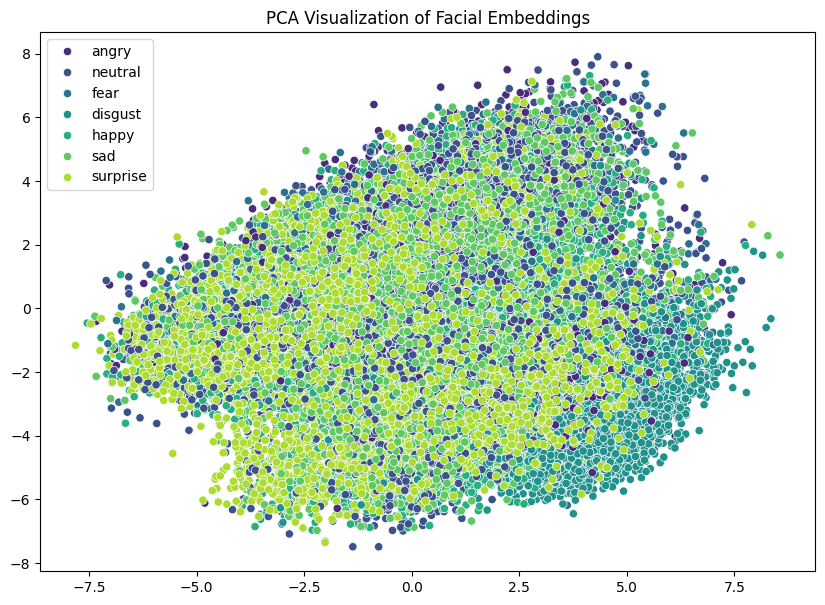

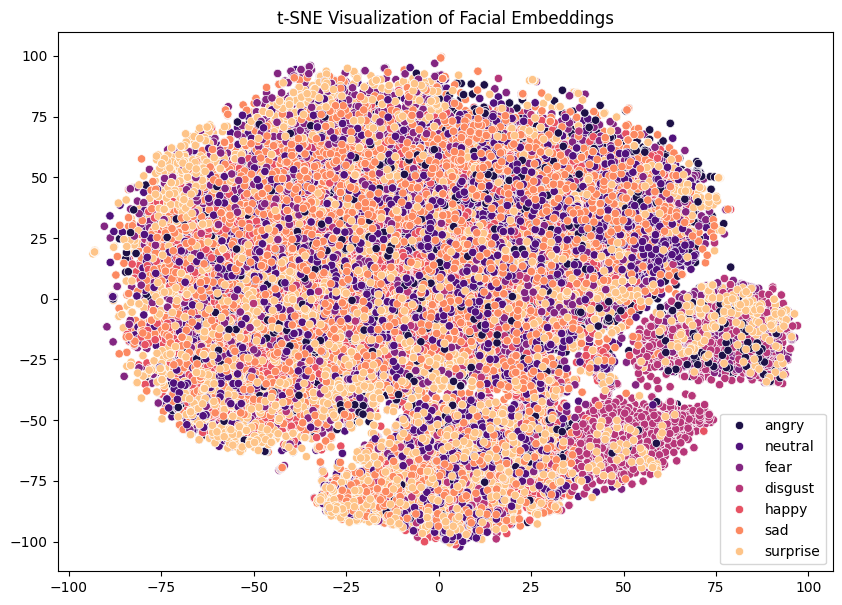

In [ ]:
print("Generating Visualizations...")

# 1. PCA
pca = PCA(n_components=2, random_state=SEED)
pca_results = pca.fit_transform(face_embeddings)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_results[:,0], y=pca_results[:,1], hue=[class_names[i] for i in face_labels], palette='viridis')
plt.title("PCA Visualization of Facial Embeddings")
plt.savefig(os.path.join(OUTPUT_DIR, "pca_visualization.png"))
plt.show()

# 2. t-SNE
tsne = TSNE(n_components=2, random_state=SEED, n_jobs=-1)
tsne_results = tsne.fit_transform(face_embeddings)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], hue=[class_names[i] for i in face_labels], palette='magma')
plt.title("t-SNE Visualization of Facial Embeddings")
plt.savefig(os.path.join(OUTPUT_DIR, "tsne_visualization.png"))
plt.show()

In [ ]:
# Save data files
np.save(os.path.join(OUTPUT_DIR, 'face_embeddings.npy'), face_embeddings)
np.save(os.path.join(OUTPUT_DIR, 'face_labels.npy'), face_labels)
np.save(os.path.join(OUTPUT_DIR, 'class_names.npy'), np.array(class_names))
metadata_df.to_csv(os.path.join(OUTPUT_DIR, 'embedding_metadata.csv'), index=False)

print("\n--- PIPELINE COMPLETE ---")
print(f"Embeddings: {os.path.join(OUTPUT_DIR, 'face_embeddings.npy')}")
print(f"Labels: {os.path.join(OUTPUT_DIR, 'face_labels.npy')}")
print(f"Metadata: {os.path.join(OUTPUT_DIR, 'embedding_metadata.csv')}")
print(f"Visuals: PCA/t-SNE saved in {OUTPUT_DIR}")


--- PIPELINE COMPLETE ---
Embeddings: /content/drive/MyDrive/Face_Embeddings_Output/face_embeddings.npy
Labels: /content/drive/MyDrive/Face_Embeddings_Output/face_labels.npy
Metadata: /content/drive/MyDrive/Face_Embeddings_Output/embedding_metadata.csv
Visuals: PCA/t-SNE saved in /content/drive/MyDrive/Face_Embeddings_Output
